### <center>Safe City Project</center>
### <center>Submitted by </center>
### <center>Aziz ul haq</center>

### Safe City Project: Crime Prediction for Rawalpindi and Islamabad

### 1. Project Objective:
- The goal is to predict the likelihood of a crime occurring in different areas based on historical data, using machine learning algorithms. This can be helpful for urban planning, law enforcement, and improving public safety.

### 2. Data Collection (Simulated Raw Data):
- We will simulate some crime data that includes features such as:

- Location: Geographical location within Rawalpindi and Islamabad.
- Time of Day: The time the crime occurred (morning, afternoon, night).
- Crime Type: The type of crime (e.g., theft, assault, vandalism).
- Weather Condition: Weather conditions at the time of the crime (sunny, rainy, etc.).
- Area Type: Whether the area is residential, commercial, or industrial.
- Crime Occurrence: Whether a crime occurred (1) or not (0).
- Here is the Python code to simulate and process the data:

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Simulating raw crime data
data = {
    'Location': ['Rawalpindi', 'Islamabad', 'Rawalpindi', 'Islamabad', 'Rawalpindi', 'Islamabad', 'Rawalpindi', 'Islamabad'],
    'Time_of_Day': ['Morning', 'Afternoon', 'Night', 'Morning', 'Afternoon', 'Night', 'Morning', 'Night'],
    'Crime_Type': ['Theft', 'Assault', 'Vandalism', 'Theft', 'Assault', 'Theft', 'Vandalism', 'Assault'],
    'Weather_Condition': ['Sunny', 'Rainy', 'Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy'],
    'Area_Type': ['Residential', 'Commercial', 'Residential', 'Commercial', 'Industrial', 'Residential', 'Commercial', 'Industrial'],
    'Crime_Occurred': [1, 1, 0, 1, 0, 1, 0, 1]
}

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df)

     Location Time_of_Day Crime_Type Weather_Condition    Area_Type  \
0  Rawalpindi     Morning      Theft             Sunny  Residential   
1   Islamabad   Afternoon    Assault             Rainy   Commercial   
2  Rawalpindi       Night  Vandalism             Sunny  Residential   
3   Islamabad     Morning      Theft             Rainy   Commercial   
4  Rawalpindi   Afternoon    Assault             Sunny   Industrial   
5   Islamabad       Night      Theft             Sunny  Residential   
6  Rawalpindi     Morning  Vandalism             Rainy   Commercial   
7   Islamabad       Night    Assault             Rainy   Industrial   

   Crime_Occurred  
0               1  
1               1  
2               0  
3               1  
4               0  
5               1  
6               0  
7               1  


### Explanation:
- Data: We define the raw crime data in a Python dictionary and convert it into a pandas DataFrame (df). The DataFrame has columns for location, time of day, crime type, weather condition, area type, and whether a crime occurred (Crime_Occurred).
### Columns:
- Location: Whether the crime occurred in Rawalpindi or Islamabad.
- Time_of_Day: The time period when the crime occurred.
- Crime_Type: Type of crime.
- Weather_Condition: Weather condition at the time of the crime.
- Area_Type: Type of area (residential, commercial, industrial).
- Crime_Occurred: Binary target variable (1 if a crime occurred, 0 otherwise).

### 3. Data Preprocessing (Converting Categorical Variables):
#### Before we train the machine learning model, we need to process the data. Many machine learning algorithms can only work with numerical data, so we need to convert categorical variables (like Location, Time_of_Day, etc.) into numeric representations.

In [2]:
# Convert categorical variables into dummy/indicator variables
df = pd.get_dummies(df, drop_first=True)

# Display the processed DataFrame
print(df)

   Crime_Occurred  Location_Rawalpindi  Time_of_Day_Morning  \
0               1                 True                 True   
1               1                False                False   
2               0                 True                False   
3               1                False                 True   
4               0                 True                False   
5               1                False                False   
6               0                 True                 True   
7               1                False                False   

   Time_of_Day_Night  Crime_Type_Theft  Crime_Type_Vandalism  \
0              False              True                 False   
1              False             False                 False   
2               True             False                  True   
3              False              True                 False   
4              False             False                 False   
5               True              True          

### Explanation:
- pd.get_dummies(): This function converts categorical variables into dummy/indicator variables (also known as one-hot encoding). For example:
- Location will be converted into two columns: Location_Islamabad and Location_Rawalpindi.
- Time_of_Day will be converted into columns like Time_of_Day_Afternoon, Time_of_Day_Morning, and Time_of_Day_Night.
- The parameter drop_first=True is used to avoid multicollinearity by removing the first category (it becomes the reference category).

#### After this step, the dataset looks like this:
Crime_Occurred	Location_Islamabad	Time_of_Day_Afternoon	Time_of_Day_Morning	Time_of_Day_Night	Crime_Type_Assault	Crime_Type_Theft	Crime_Type_Vandalism	Weather_Condition_Rainy	Area_Type_Industrial	Area_Type_Residential
1	0	0	1	0	0	1	0	1	0	1
1	1	1	0	0	1	0	0	0	0	0
0	0	0	0	1	0	0	1	1	0	1
1	1	0	1	0	0	1	0	0	1	0
0	0	1	0	0	1	0	0	1	0	1
1	1	0	0	1	0	1	0	1

### 4. Model Training:
- Next, we'll train a machine learning model to predict whether a crime will occur based on the input features.

In [3]:
# Define features (X) and target (y)
X = df.drop('Crime_Occurred', axis=1)  # Drop target column
y = df['Crime_Occurred']  # Target variable

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a logistic regression model
model = LogisticRegression()

# Train the model using the training data
model.fit(X_train, y_train)

LogisticRegression()

### Explanation:
- X = df.drop('Crime_Occurred', axis=1): This defines the features (X) by removing the target variable (Crime_Occurred).
- y = df['Crime_Occurred']: This defines the target variable (y), which we want to predict.
- train_test_split(): Splits the data into training (80%) and testing (20%) sets. This ensures that we train the model on one portion and test its performance on a different portion.
- LogisticRegression(): We use a logistic regression model because the target variable is binary (0 or 1).
- model.fit(X_train, y_train): This trains the logistic regression model using the training data.

### 5. Model Evaluation:
- After training the model, we need to evaluate its performance using the test data.

Model Accuracy: 100.00%
Confusion Matrix:
[[2]]


C:\Users\DELL XPS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


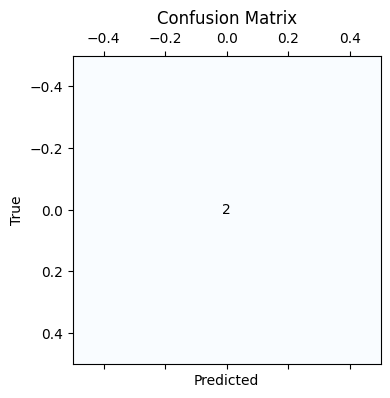

In [4]:
# Predict crime occurrences on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plotting the confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ax.matshow(cm, cmap='Blues', alpha=0.7)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Explanation:
- model.predict(X_test): Makes predictions using the trained model on the test set.
- accuracy_score(y_test, y_pred): Calculates the accuracy of the model by comparing the true values (y_test) with the - predicted values (y_pred).
- confusion_matrix(y_test, y_pred): Computes the confusion matrix, which shows the true positive, true negative, false - positive, and false negative counts. It helps us understand how well the model is performing.
- Confusion Matrix Plot: The confusion matrix is visualized as a heatmap for better interpretation.

### 6. Conclusion:
##### This example demonstrates how to create a basic crime prediction model for the Safe City project in Rawalpindi and Islamabad using machine learning. The model uses several factors (location, time, weather, etc.) to predict whether a crime will occur. By analyzing the predictions and confusion matrix, authorities can focus on areas with a higher likelihood of crime, enhancing public safety.